# Edge Intensity Histograms for HCP-1200 FC Metrics

This notebook computes and visualizes edge intensity distributions for all 173 unique functional connectivity metric/lag combinations:
- 149 PySPI metrics (no lag)
- 24 Skarf metrics (12 functions × 2 lags)

**Analysis approach:**
1. For each metric/lag combination, extract all edge values from connectivity matrices
2. **Symmetric matrices (M - M^T ≈ 0):** Extract only upper triangle (excluding diagonal) to avoid double-counting edges
3. **Antisymmetric matrices (M + M^T ≈ 0):** Extract only upper triangle (excluding diagonal) since lower triangle is redundant (negated values)
4. Pool edges across all subjects, sessions, and runs
5. **Preserve raw edge values** (no absolute value, no normalization)
6. Bin raw values into 100 histogram bins with dynamic range per metric
7. Visualize all histograms in a faceted grid plot

**Excluded metrics:** Degenerate metrics are excluded based on the `matrix_degenerate_lookup.json`. A metric is considered degenerate if:
- All values are essentially zero (max|M| < 1e-10)
- Constant matrix (single unique value = no inter-edge variation)

## Setup and Imports

In [1]:
import json
import os
from pathlib import Path
from math import ceil

import numpy as np
import pandas as pd
import polars as pl
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from tqdm.auto import tqdm

from arfcexp.matrices import EfficientMatrixReader

# Load matplotlib style
style_path = os.environ.get("MPL_STYLE")
if style_path:
    plt.style.use(style_path)

# Get plot parameters
PLOTW, PLOTH = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

print(f"Plot size: {PLOTW} x {PLOTH}")
print(f"Output format: {FORMAT}")
print(f"Color cycle: {color_cycle[:3]}...") 

Plot size: 3.42 x 2.565
Output format: png
Color cycle: ['#348ABD', '#A60628', '#7A68A6']...


## Configuration and Paths

In [2]:
# Data paths
project_root = Path(os.environ["PROJECT_ROOT"])
parquet_path = Path("/srv/projects/skarf/data_aggregation/hcp_1200_rfmri_schaefer.parquet")
output_dir = Path("/home/aerkent/skarf-experiments/results/hcp_1200_edge_intensity_distributions")
symmetry_lookup_path = project_root / "resources/matrix_symmetry_lookup.json"
antisymmetry_lookup_path = project_root / "resources/matrix_antisymmetry_lookup.json"
degenerate_lookup_path = project_root / "resources/matrix_degenerate_lookup.json"

# Configuration
N_BINS = 100
N_ROIS = 200
N_EDGES_FULL = N_ROIS * N_ROIS  # 40,000 edges per full matrix
N_EDGES_TRIU = N_ROIS * (N_ROIS - 1) // 2  # 19,900 unique edges (upper triangle, no diagonal)

# Create reader instance (builds lightweight index once, reuses for all queries)
reader = EfficientMatrixReader(parquet_path)

print(f"Parquet path: {parquet_path}")
print(f"Output directory: {output_dir}")
print(f"Reader index: {len(reader.index):,} rows")

print(f"\nConfiguration:")
print(f"  Edges per symmetric/antisymmetric matrix (upper triangle): {N_EDGES_TRIU:,}")
print(f"  Edges per full matrix: {N_EDGES_FULL:,}")
print(f"  Histogram bins: {N_BINS}")
print(f"  ROIs: {N_ROIS}")

Parquet path: /srv/projects/skarf/data_aggregation/hcp_1200_rfmri_schaefer.parquet
Output directory: /home/aerkent/skarf-experiments/results/hcp_1200_edge_intensity_distributions
Reader index: 596,532 rows

Configuration:
  Edges per symmetric/antisymmetric matrix (upper triangle): 19,900
  Edges per full matrix: 40,000
  Histogram bins: 100
  ROIs: 200


## Load Matrix Symmetry Lookups

In [3]:
# Load symmetry lookup from JSON
with open(symmetry_lookup_path, 'r') as f:
    symmetry_lookup = json.load(f)

# Load antisymmetry lookup from JSON
with open(antisymmetry_lookup_path, 'r') as f:
    antisymmetry_lookup = json.load(f)

# Load degenerate lookup from JSON
with open(degenerate_lookup_path, 'r') as f:
    degenerate_lookup = json.load(f)

print(f"Loaded symmetry information for {len(symmetry_lookup)} method/func combinations")
print(f"Loaded antisymmetry information for {len(antisymmetry_lookup)} method/func combinations")
print(f"Loaded degenerate information for {len(degenerate_lookup)} method/func combinations")

# Count symmetric vs non-symmetric
n_symmetric = sum(symmetry_lookup.values())
n_nonsymmetric = len(symmetry_lookup) - n_symmetric

# Count antisymmetric
n_antisymmetric = sum(antisymmetry_lookup.values())

# Count degenerate
n_degenerate = sum(degenerate_lookup.values())

print(f"\nMatrix classification breakdown:")
print(f"  Symmetric matrices (M - M^T ≈ 0): {n_symmetric}")
print(f"  Antisymmetric matrices (M + M^T ≈ 0): {n_antisymmetric}")
print(f"  Degenerate matrices (to exclude): {n_degenerate}")
print(f"  Other (general): {len(symmetry_lookup) - n_symmetric - n_antisymmetric}")

# Show degenerate metrics
print(f"\nDegenerate metrics to exclude:")
for key, is_degenerate in degenerate_lookup.items():
    if is_degenerate:
        print(f"  {key}")

Loaded symmetry information for 161 method/func combinations
Loaded antisymmetry information for 161 method/func combinations
Loaded degenerate information for 161 method/func combinations

Matrix classification breakdown:
  Symmetric matrices (M - M^T ≈ 0): 104
  Antisymmetric matrices (M + M^T ≈ 0): 13
  Degenerate matrices (to exclude): 2
  Other (general): 44

Degenerate metrics to exclude:
  pyspi__bary_euclidean_mean
  pyspi__lmfit_Lasso


## Load and Inspect Parquet Data

In [4]:
# Inspect the lightweight index (all columns except mat/scores/err)
print(f"Index schema: {reader.index.columns}")
print(f"Index shape: {reader.index.shape}")

# Preview first few rows
print(f"\nPreview (first 5 rows):")
reader.index.select(["method", "func_id", "func", "lag", "success", "sub", "ses", "run"]).head(5)

Index schema: ['index', 'method', 'func_id', 'sub_id', 'func', 'sub', 'ses', 'run', 'success', 'run_time', 'peak_mem_mb', 'train_score', 'val_score', 'test_score', 'lag']
Index shape: (596532, 15)

Preview (first 5 rows):


method,func_id,func,lag,success,sub,ses,run
str,i32,str,i64,bool,str,u8,u8
"""pyspi""",0,"""cov_EmpiricalCovariance""",null,true,"""181131""",1,1
"""pyspi""",0,"""cov_EmpiricalCovariance""",null,true,"""181131""",1,2
"""pyspi""",0,"""cov_EmpiricalCovariance""",null,true,"""181131""",2,1
"""pyspi""",0,"""cov_EmpiricalCovariance""",null,true,"""181131""",2,2
"""pyspi""",0,"""cov_EmpiricalCovariance""",null,true,"""245333""",1,1


In [5]:
# Check success rate from the index
total = len(reader.index)
success = reader.index["success"].sum()
failed = total - success

print(f"Total rows: {total:,}")
print(f"Successful runs: {success:,} ({100*success/total:.2f}%)")
print(f"Failed runs: {failed:,} ({100*failed/total:.2f}%)")

Total rows: 596,532
Successful runs: 595,662 (99.85%)
Failed runs: 870 (0.15%)


## Identify Unique Metric/Lag Combinations

In [6]:
# Get unique metric/lag combinations (only successful runs) from the index
unique_metrics_df = (
    reader.index
    .filter(reader.index["success"])
    .select(["method", "func_id", "func", "lag"])
    .unique()
    .sort(["method", "func_id", "lag"])
)

print(f"Total unique metric/lag combinations: {len(unique_metrics_df)}")
print(f"\nBreakdown by method:")

method_counts = unique_metrics_df.group_by("method").agg(pl.len()).sort("method")
print(method_counts)

# Create list of tuples for iteration
metric_keys = [
    (row["method"], row["func_id"], row["func"], row["lag"])
    for row in unique_metrics_df.iter_rows(named=True)
]

print(f"\nFirst 5 metric keys:")
for i, key in enumerate(metric_keys[:5]):
    print(f"  {i+1}. {key}")

print(f"\nLast 5 metric keys:")
for i, key in enumerate(metric_keys[-5:]):
    print(f"  {len(metric_keys)-4+i}. {key}")

Total unique metric/lag combinations: 173

Breakdown by method:
shape: (2, 2)
┌────────┬─────┐
│ method ┆ len │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ pyspi  ┆ 149 │
│ skarf  ┆ 24  │
└────────┴─────┘

First 5 metric keys:
  1. ('pyspi', 0, 'cov_EmpiricalCovariance', None)
  2. ('pyspi', 1, 'cov_EllipticEnvelope', None)
  3. ('pyspi', 3, 'cov_GraphicalLassoCV', None)
  4. ('pyspi', 4, 'cov_LedoitWolf', None)
  5. ('pyspi', 5, 'cov_MinCovDet', None)

Last 5 metric keys:
  169. ('skarf', 9, 'linear_enet-pos', 1)
  170. ('skarf', 10, 'linear_pls', 0)
  171. ('skarf', 10, 'linear_pls', 1)
  172. ('skarf', 11, 'linear_pca-ridge', 0)
  173. ('skarf', 11, 'linear_pca-ridge', 1)


## Define Helper Functions

In [7]:
def compute_histogram_from_matrices(matrices, is_symmetric, is_antisymmetric, n_bins=100, n_rois=200):
    """
    Compute histogram of raw edge values from pre-loaded connectivity matrices.
    
    For symmetric matrices (M - M^T ≈ 0), extracts only upper triangle (excluding diagonal).
    For antisymmetric matrices (M + M^T ≈ 0), extracts only upper triangle (lower is redundant).
    For other matrices, uses all edges.
    No absolute value or normalization applied.
    
    Args:
        matrices: List of flattened matrices as numpy arrays.
        is_symmetric: Whether the matrix type is symmetric.
        is_antisymmetric: Whether the matrix type is antisymmetric.
        n_bins: Number of histogram bins.
        n_rois: Number of ROIs (default: 200).
    
    Returns:
        dict with keys: counts (array), bin_edges (array), n_matrices (int), 
                        min_val (float), max_val (float), n_edges (int), 
                        is_symmetric (bool), is_antisymmetric (bool)
    """
    if len(matrices) == 0:
        return None
    
    # Use upper triangle for symmetric OR antisymmetric matrices
    use_upper_triangle = is_symmetric or is_antisymmetric
    
    # Extract edges from all matrices
    all_edges = []
    for mat_flat in matrices:
        mat_2d = mat_flat.reshape(n_rois, n_rois)
        
        if use_upper_triangle:
            edges = mat_2d[np.triu_indices(n_rois, k=1)]
        else:
            edges = mat_2d.flatten()
        
        all_edges.append(edges)
    
    # Concatenate all edge values into a single array
    edges_all = np.concatenate(all_edges)
    del all_edges
    
    # Filter out NaN values (some metrics have NaN on diagonal)
    edges_valid = edges_all[~np.isnan(edges_all)]
    del edges_all
    
    if len(edges_valid) == 0:
        return None
    
    min_val = float(np.min(edges_valid))
    max_val = float(np.max(edges_valid))
    n_edges = len(edges_valid)
    
    counts, bin_edges = np.histogram(edges_valid, bins=n_bins, range=(min_val, max_val))
    del edges_valid
    
    return {
        "counts": counts,
        "bin_edges": bin_edges,
        "n_matrices": len(matrices),
        "n_edges": n_edges,
        "min_val": min_val,
        "max_val": max_val,
        "is_symmetric": is_symmetric,
        "is_antisymmetric": is_antisymmetric,
    }


def create_metric_label(method, func_id, func, lag):
    """Create a readable label for a metric/lag combination."""
    if method == "skarf":
        return f"{method}_{func_id:03d}_{func}_lag{int(lag)}"
    else:
        return f"{method}_{func_id:03d}_{func}"

In [8]:
def process_single_metric(metric_key, reader, symmetry_lookup, antisymmetry_lookup, n_bins, n_rois):
    """
    Load matrices via EfficientMatrixReader and compute edge histogram.
    
    Args:
        metric_key: Tuple of (method, func_id, func, lag)
        reader: EfficientMatrixReader instance (shared across calls)
        symmetry_lookup: Dict mapping "method__func" to is_symmetric (bool)
        antisymmetry_lookup: Dict mapping "method__func" to is_antisymmetric (bool)
        n_bins: Number of bins for histogram
        n_rois: Number of ROIs
    
    Returns:
        Dictionary with metric information and histogram data, or None if failed
    """
    method, func_id, func, lag = metric_key
    
    matrices = reader.get_matrices(method=method, func=func, success=True, func_id=func_id, lag=lag)
    
    lookup_key = f"{method}__{func}"
    is_symmetric = symmetry_lookup.get(lookup_key, False)
    is_antisymmetric = antisymmetry_lookup.get(lookup_key, False)
    
    result = compute_histogram_from_matrices(
        matrices, is_symmetric, is_antisymmetric, n_bins=n_bins, n_rois=n_rois
    )
    
    if result is None:
        print(f"Warning: No data found for {method}/{func_id}/{func}/lag={lag}")
        return None
    
    return {
        "method": method,
        "func_id": func_id,
        "func": func,
        "lag": lag if method == "skarf" else None,
        "label": create_metric_label(method, func_id, func, lag),
        "n_matrices": result["n_matrices"],
        "n_edges": result["n_edges"],
        "min_val": result["min_val"],
        "max_val": result["max_val"],
        "is_symmetric": result["is_symmetric"],
        "is_antisymmetric": result["is_antisymmetric"],
        "counts": result["counts"].tolist(),
        "bin_edges": result["bin_edges"].tolist(),
    }

## Compute Histograms for All Metrics

In [9]:
# Check if results already exist
histogram_results_path = output_dir / "edge_intensity_histograms_data.parquet"

# Filter out degenerate metrics using the degenerate lookup
# The lookup key format is "method__func"
metric_keys_filtered = [
    key for key in metric_keys 
    if not degenerate_lookup.get(f"{key[0]}__{key[2]}", False)  # key[0]=method, key[2]=func
]

print(f"Filtered out {len(metric_keys) - len(metric_keys_filtered)} degenerate metrics")
print(f"Remaining metrics to process: {len(metric_keys_filtered)}")

if histogram_results_path.exists():
    print(f"\nLoading existing histogram data from {histogram_results_path}...")
    histogram_results_df = pd.read_parquet(histogram_results_path)
    print(f"Loaded {len(histogram_results_df)} histogram records")
    
else:
    print(f"\nComputing histograms for {len(metric_keys_filtered)} metrics...")
    print(f"This will process {success:,} connectivity matrices.\n")
    
    # Sequential processing
    histogram_results = []
    for metric_key in tqdm(metric_keys_filtered, desc="Processing metrics"):
        result = process_single_metric(metric_key, reader, symmetry_lookup, antisymmetry_lookup, N_BINS, N_ROIS)
        histogram_results.append(result)
    
    # Filter out None results (failed computations)
    histogram_results = [r for r in histogram_results if r is not None]
    
    # Convert to DataFrame
    histogram_results_df = pd.DataFrame(histogram_results)
    
    print(f"\nCompleted histogram computation for {len(histogram_results_df)} metrics.")
    print(f"\nSummary:")
    print(f"  Total metrics processed: {len(histogram_results_df)}")
    print(f"  PySPI metrics: {len(histogram_results_df[histogram_results_df['method'] == 'pyspi'])}")
    print(f"  Skarf metrics: {len(histogram_results_df[histogram_results_df['method'] == 'skarf'])}")

histogram_results_df.head()

Filtered out 2 degenerate metrics
Remaining metrics to process: 171

Loading existing histogram data from /home/aerkent/skarf-experiments/results/hcp_1200_edge_intensity_distributions/edge_intensity_histograms_data.parquet...
Loaded 171 histogram records


,method,func_id,func,lag,label,n_matrices,n_edges,min_val,max_val,is_symmetric,is_antisymmetric,counts,bin_edges
0,pyspi,0,cov_EmpiricalCovariance,NaN,pyspi_000_cov_EmpiricalCovariance,3468,69013200,-0.908607,0.987392,True,False,"[1, 8, 23, 90, 314, 664, 1324, 2465, 4397, 723...","[-0.9086070656776428, -0.8896470665931702, -0...."
1,pyspi,1,cov_EllipticEnvelope,NaN,pyspi_001_cov_EllipticEnvelope,3468,69013200,-0.973618,1.265716,True,False,"[4, 7, 39, 115, 253, 547, 1154, 2175, 4073, 69...","[-0.97361820936203, -0.9512248635292053, -0.92..."
2,pyspi,3,cov_GraphicalLassoCV,NaN,pyspi_003_cov_GraphicalLassoCV,3323,66127700,-0.627521,0.768779,True,False,"[4, 17, 42, 57, 156, 278, 475, 788, 1319, 1993...","[-0.6275214552879333, -0.6135584712028503, -0...."
3,pyspi,4,cov_LedoitWolf,NaN,pyspi_004_cov_LedoitWolf,3468,69013200,-0.881862,0.959355,True,False,"[2, 9, 22, 88, 300, 662, 1227, 2311, 4091, 678...","[-0.8818620443344116, -0.8634498715400696, -0...."
4,pyspi,5,cov_MinCovDet,NaN,pyspi_005_cov_MinCovDet,3468,69013200,-0.978335,1.197067,True,False,"[3, 14, 28, 81, 187, 395, 863, 1645, 2847, 486...","[-0.978334903717041, -0.9565808773040771, -0.9..."


## Save Histogram Data

In [10]:
if not histogram_results_path.exists():
    # Save to parquet
    histogram_results_df.to_parquet(histogram_results_path, index=False)
    print(f"Saved histogram data to: {histogram_results_path}")
    
    # Get file size
    file_size_mb = histogram_results_path.stat().st_size / (1024**2)
    print(f"File size: {file_size_mb:.2f} MB")
else:
    print(f"Histogram data already saved at: {histogram_results_path}")

Histogram data already saved at: /home/aerkent/skarf-experiments/results/hcp_1200_edge_intensity_distributions/edge_intensity_histograms_data.parquet


## Create Faceted Histogram Plot

Creating faceted plot with 11 rows × 16 columns
Total subplots: 176 (for 171 metrics)


Plotting histograms:   0%|          | 0/171 [00:00<?, ?it/s]


Saved faceted plot to: /home/aerkent/skarf-experiments/results/hcp_1200_edge_intensity_distributions/edge_intensity_histograms_faceted.png


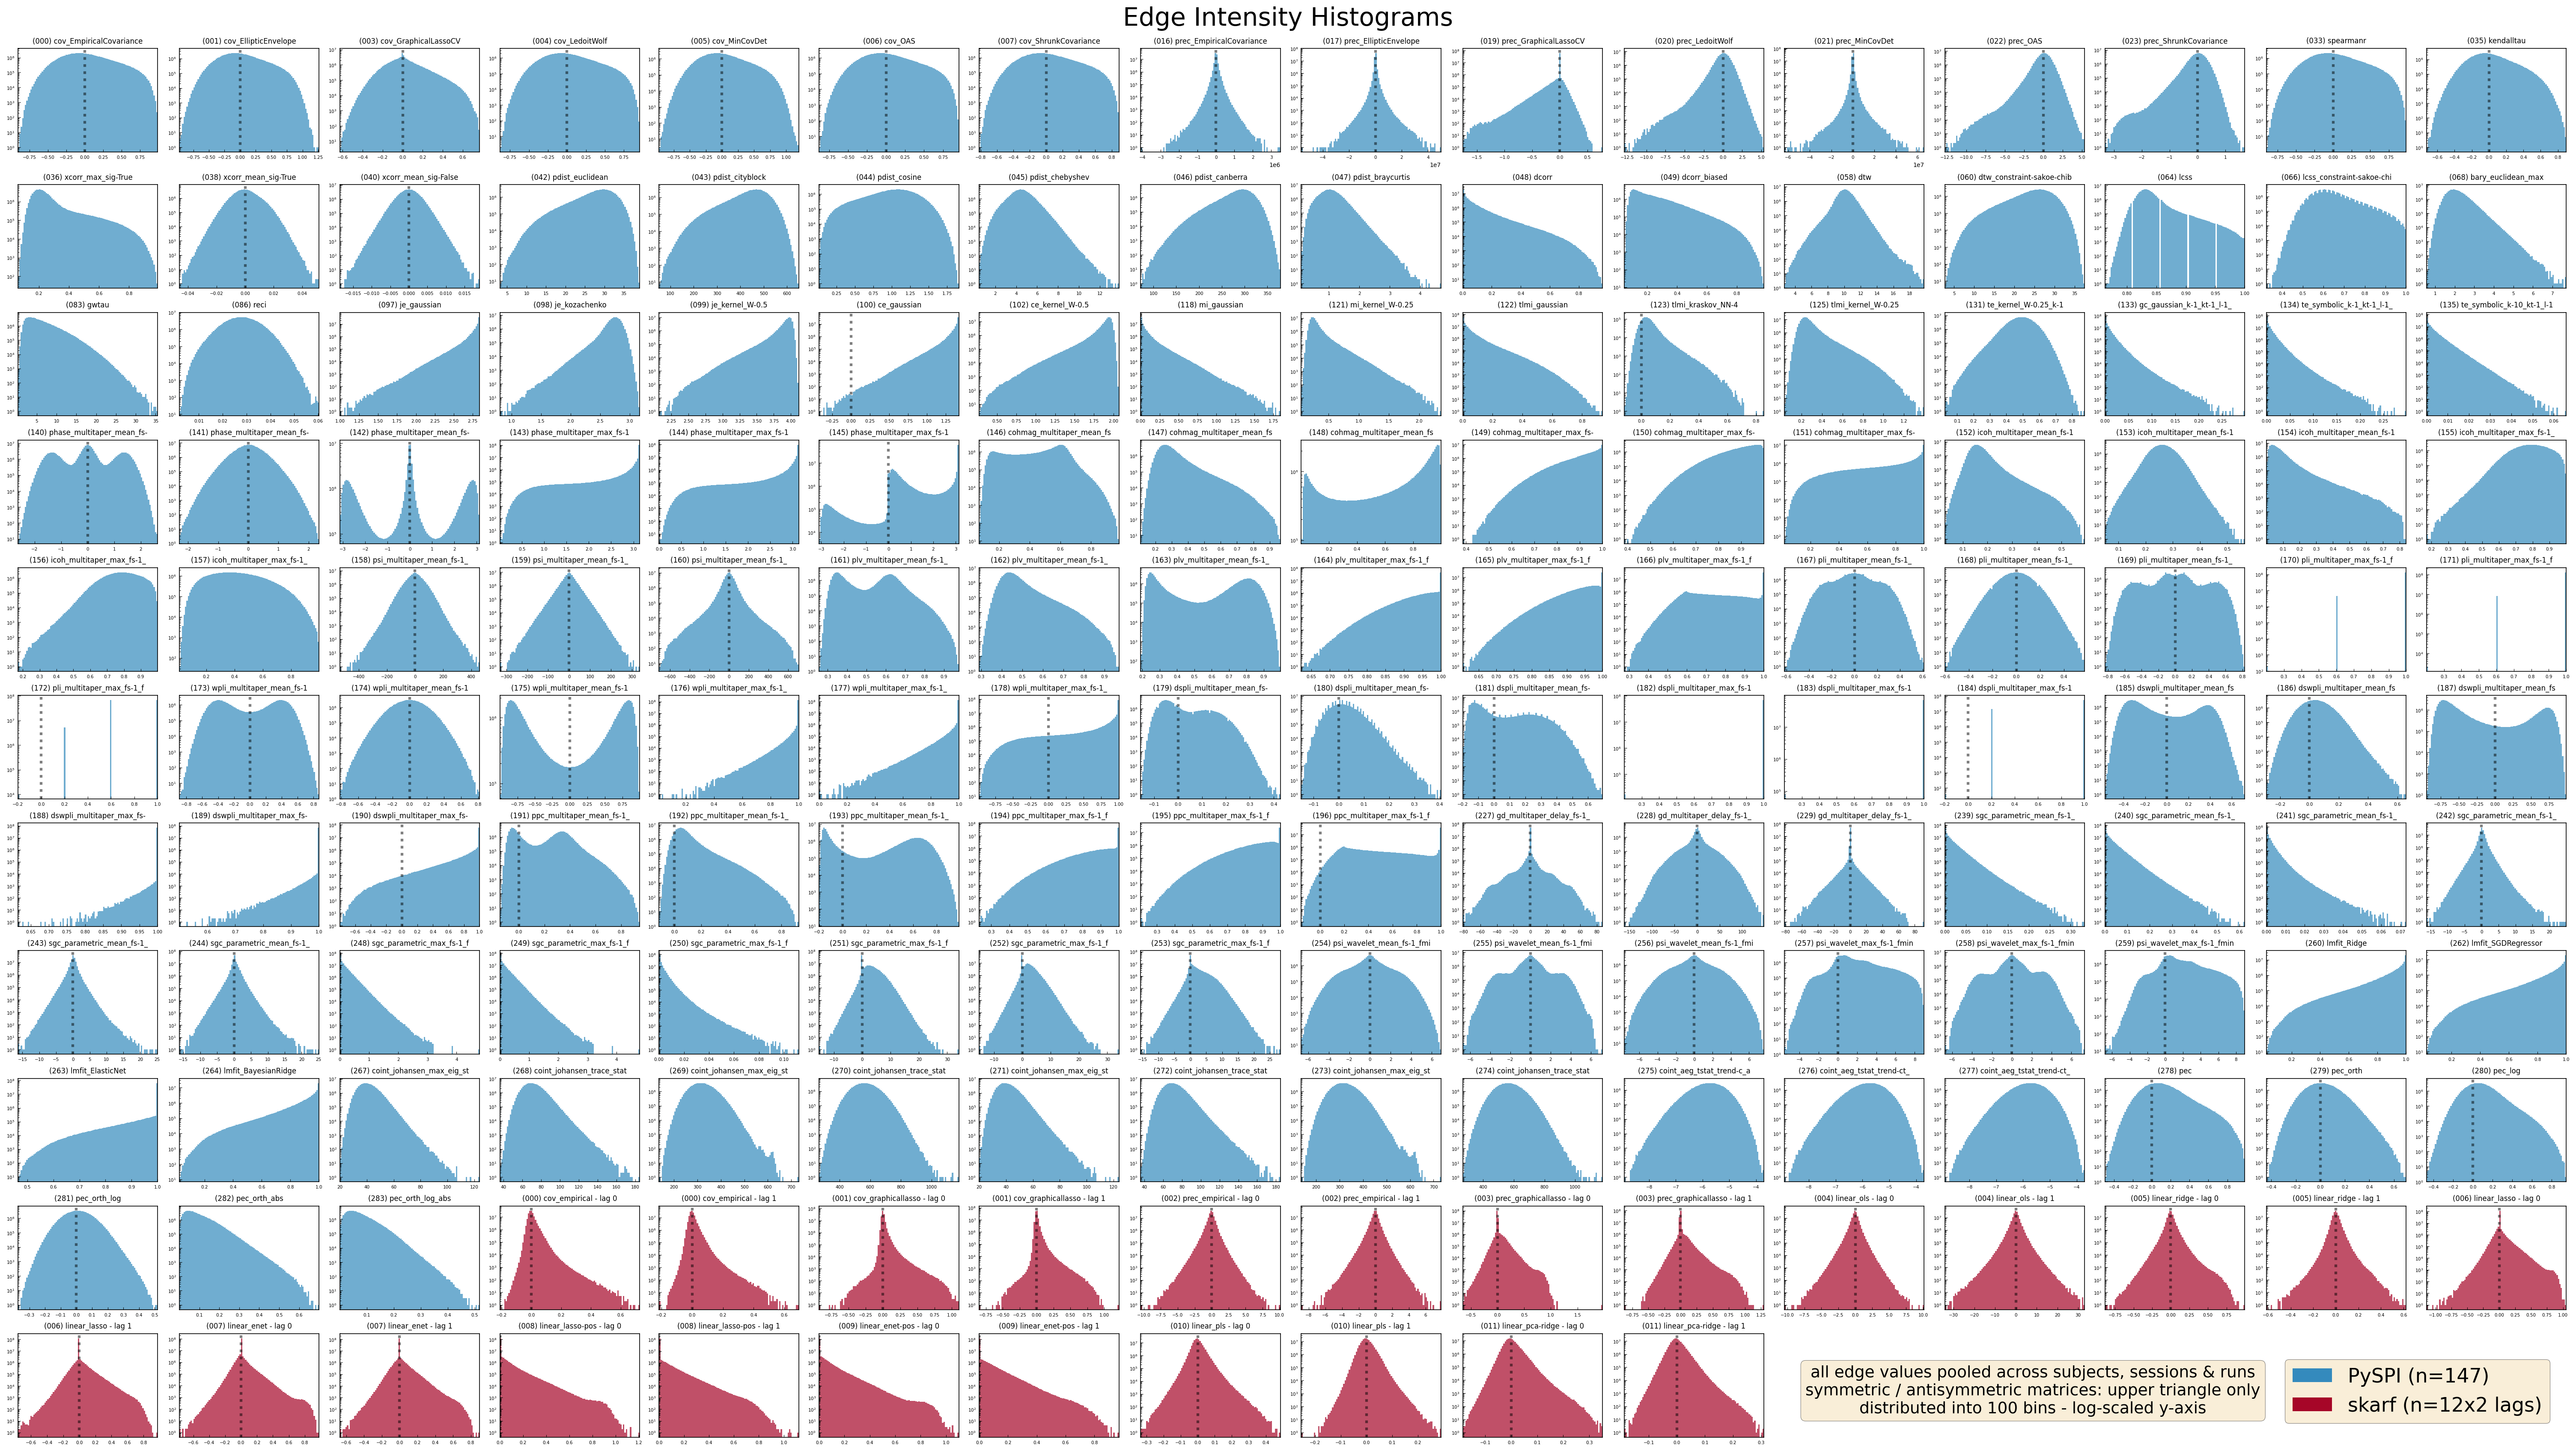

In [11]:
# Calculate grid dimensions (approximately square)
n_metrics = len(histogram_results_df)
n_cols = 16
n_rows = ceil(n_metrics / n_cols)

print(f"Creating faceted plot with {n_rows} rows × {n_cols} columns")
print(f"Total subplots: {n_rows * n_cols} (for {n_metrics} metrics)")

# Create figure
fig, axes = plt.subplots(
    n_rows, n_cols, 
    figsize=(n_cols * 2.5, n_rows * 2),
    constrained_layout=True
)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Define colors for methods
method_colors = {
    "pyspi": color_cycle[0],  # First color in cycle
    "skarf": color_cycle[1],  # Second color in cycle
}

# Sort DataFrame for plotting
histogram_results_df_sorted = histogram_results_df.sort_values(
    ["method", "func_id", "lag"]
).reset_index(drop=True)

# Plot each histogram
for idx, row in enumerate(tqdm(histogram_results_df_sorted.iterrows(), 
                                total=n_metrics, 
                                desc="Plotting histograms")):
    _, data = row
    ax = axes_flat[idx]
    
    # Get histogram data
    counts = np.array(data["counts"])
    bin_edges = np.array(data["bin_edges"])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Get color
    color = method_colors[data["method"]]
    
    # Plot bar chart
    ax.bar(bin_centers, counts, width=bin_width, color=color, alpha=0.7, edgecolor="none")
    
    # Create title
    if data["method"] == "skarf":
        title = f"({data['func_id']:03d}) {data['func'][:20]} - lag {int(data['lag'])}"
    else:
        title = f"({data['func_id']:03d}) {data['func'][:25]}"
    
    ax.set_title(title, fontsize=8)
    # Use dynamic x-axis based on actual data range
    ax.set_xlim(bin_edges[0], bin_edges[-1])
    
    # Add vertical line at x=0 if it's within the data range
    if bin_edges[0] <= 0 <= bin_edges[-1]:
        ax.axvline(0, color='black', linestyle=':', linewidth=3, alpha=0.5)
    
    ax.tick_params(axis="both", labelsize=5)
    ax.set_xlabel("", fontsize=5)
    ax.set_ylabel("", fontsize=5)
    ax.set_yscale("log")
    ax.grid(False)
    
# Hide unused subplots
for idx in range(n_metrics, len(axes_flat)):
    axes_flat[idx].axis("off")

# Add overall title
n_pyspi_plot = len(histogram_results_df[histogram_results_df["method"] == "pyspi"])
n_skarf_plot = len(histogram_results_df[histogram_results_df["method"] == "skarf"])
fig.suptitle(
    f"Edge Intensity Histograms",
    fontsize=28,
    y=1.02,
)

# Add legend
legend_elements = [
    Patch(facecolor=method_colors["pyspi"], edgecolor="none", label=f"PySPI (n={n_pyspi_plot})"),
    Patch(facecolor=method_colors["skarf"], edgecolor="none", label=f"skarf (n={n_skarf_plot//2}x2 lags)"),
]
fig.legend(handles=legend_elements, loc="lower right", fontsize=22,
           bbox_to_anchor=(0.995, 0.01), 
           facecolor='wheat',
           edgecolor='black',
           framealpha=0.5
)

# Add a textbox to the left of the legend
fig.text(0.79, 0.04,
    "all edge values pooled across subjects, sessions & runs\n"
    "symmetric / antisymmetric matrices: upper triangle only\n"
    "distributed into 100 bins - log-scaled y-axis",
    fontdict={"fontsize": 18, "color": "black", "ha": "center", "va": "center"},
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5, edgecolor='black'),
)

# Save figure
output_path = output_dir / f"edge_intensity_histograms_faceted.{FORMAT}"
fig.savefig(output_path, dpi=600, bbox_inches="tight")
print(f"\nSaved faceted plot to: {output_path}")

plt.show()

## Compute Summary Statistics

In [12]:
def compute_histogram_stats(counts, bin_edges):
    """
    Compute statistics from histogram data (raw edge values).
    
    Returns:
        dict with mean, median, std, mode (bin with max count)
    """
    counts = np.array(counts)
    bin_edges = np.array(bin_edges)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Normalize counts to probabilities
    total = counts.sum()
    if total == 0:
        return {"mean": np.nan, "median": np.nan, "std": np.nan, "mode": np.nan}
    
    probs = counts / total
    
    # Weighted mean
    mean = np.sum(bin_centers * probs)
    
    # Weighted std
    variance = np.sum(probs * (bin_centers - mean) ** 2)
    std = np.sqrt(variance)
    
    # Median
    cumsum = np.cumsum(probs)
    median_idx = np.searchsorted(cumsum, 0.5)
    median = bin_centers[median_idx] if median_idx < len(bin_centers) else bin_centers[-1]
    
    # Mode
    mode_idx = np.argmax(counts)
    mode = bin_centers[mode_idx]
    
    return {
        "mean": mean,
        "median": median,
        "std": std,
        "mode": mode,
    }


# Compute statistics for each metric
print("Computing summary statistics...")

stats_records = []
for _, row in histogram_results_df.iterrows():
    stats = compute_histogram_stats(row["counts"], row["bin_edges"])
    
    record = {
        "method": row["method"],
        "func_id": row["func_id"],
        "func": row["func"],
        "lag": row["lag"],
        "label": row["label"],
        "n_matrices": row["n_matrices"],
        "n_edges": row["n_edges"],
        "is_symmetric": row["is_symmetric"],
        "is_antisymmetric": row.get("is_antisymmetric", False),
        "min_val": row["min_val"],
        "max_val": row["max_val"],
        "hist_mean": stats["mean"],
        "hist_median": stats["median"],
        "hist_std": stats["std"],
        "hist_mode": stats["mode"],
    }
    
    stats_records.append(record)

summary_stats_df = pd.DataFrame(stats_records)

print(f"\nSummary statistics computed for {len(summary_stats_df)} metrics.")
summary_stats_df.head()

Computing summary statistics...

Summary statistics computed for 171 metrics.


,method,func_id,func,lag,label,n_matrices,n_edges,is_symmetric,is_antisymmetric,min_val,max_val,hist_mean,hist_median,hist_std,hist_mode
0,pyspi,0,cov_EmpiricalCovariance,NaN,pyspi_000_cov_EmpiricalCovariance,3468,69013200,True,False,-0.908607,0.987392,-0.000427,-0.026968,0.275982,-0.083847
1,pyspi,1,cov_EllipticEnvelope,NaN,pyspi_001_cov_EllipticEnvelope,3468,69013200,True,False,-0.973618,1.265716,-0.000420,-0.021901,0.279180,-0.089081
2,pyspi,3,cov_GraphicalLassoCV,NaN,pyspi_003_cov_GraphicalLassoCV,3323,66127700,True,False,-0.627521,0.768779,0.010916,-0.006168,0.147173,-0.006168
3,pyspi,4,cov_LedoitWolf,NaN,pyspi_004_cov_LedoitWolf,3468,69013200,True,False,-0.881862,0.959355,-0.000409,-0.025696,0.265740,-0.080932
4,pyspi,5,cov_MinCovDet,NaN,pyspi_005_cov_MinCovDet,3468,69013200,True,False,-0.978335,1.197067,-0.000420,-0.032035,0.279118,-0.075543


## Display Summary Statistics

In [13]:
# Sort by histogram mean
summary_stats_sorted = summary_stats_df.sort_values("hist_mean", ascending=False)

print("Top 20 metrics by mean raw edge value:")
display(summary_stats_sorted[["method", "func_id", "func", "lag", "is_symmetric", "is_antisymmetric", "hist_mean", "hist_std", "min_val", "max_val"]].head(20))

print("Bottom 20 metrics by mean raw edge value:")
display(summary_stats_sorted[["method", "func_id", "func", "lag", "is_symmetric", "is_antisymmetric", "hist_mean", "hist_std", "min_val", "max_val"]].tail(20))

Top 20 metrics by mean raw edge value:


,method,func_id,func,lag,is_symmetric,is_antisymmetric,hist_mean,hist_std,min_val,max_val
11,pyspi,21,prec_MinCovDet,NaN,True,False,158154.296623,809210.694208,-6.368582e+07,6.616076e+07
8,pyspi,17,prec_EllipticEnvelope,NaN,True,False,132398.315239,753929.351652,-5.642288e+07,4.990752e+07
7,pyspi,16,prec_EmpiricalCovariance,NaN,True,False,6383.349155,83532.327218,-4.092392e+06,3.503908e+06
137,pyspi,274,coint_johansen_trace_stat_order-1_ardiff-1,NaN,True,False,567.487987,67.645283,2.670097e+02,1.178166e+03
133,pyspi,270,coint_johansen_trace_stat_order-0_ardiff-1,NaN,True,False,567.420033,67.635941,2.669939e+02,1.178145e+03
20,pyspi,43,pdist_cityblock,NaN,True,False,443.250768,67.713223,5.095892e+01,6.510300e+02
136,pyspi,273,coint_johansen_max_eig_stat_order-1_ardiff-1,NaN,True,False,319.977417,42.029329,1.366324e+02,7.317057e+02
132,pyspi,269,coint_johansen_max_eig_stat_order-0_ardiff-1,NaN,True,False,319.938946,42.023716,1.366264e+02,7.316076e+02
23,pyspi,46,pdist_canberra,NaN,True,False,286.412216,28.262181,7.194502e+01,3.785632e+02
131,pyspi,268,coint_johansen_trace_stat_order-0_ardiff-10,NaN,True,False,71.070426,8.992343,3.612728e+01,1.846675e+02


Bottom 20 metrics by mean raw edge value:


,method,func_id,func,lag,is_symmetric,is_antisymmetric,hist_mean,hist_std,min_val,max_val
76,pyspi,168,pli_multitaper_mean_fs-1_fmin-0_fmax-0-25,NaN,False,True,-0.002099,0.096134,-0.601980,0.574257
120,pyspi,254,psi_wavelet_mean_fs-1_fmin-0_fmax-0-5_mean,NaN,True,False,-0.003193,1.428980,-6.682512,6.898556
82,pyspi,174,wpli_multitaper_mean_fs-1_fmin-0_fmax-0-25,NaN,False,True,-0.003228,0.150734,-0.813909,0.818132
160,skarf,6,linear_lasso,1.0,False,False,-0.003751,0.034951,-0.763585,0.975257
122,pyspi,256,psi_wavelet_mean_fs-1_fmin-0-25_fmax-0-5_mean,NaN,True,False,-0.004143,1.604511,-7.664704,7.627171
9,pyspi,19,prec_GraphicalLassoCV,NaN,True,False,-0.005942,0.048252,-1.758909,0.772232
89,pyspi,181,dspli_multitaper_mean_fs-1_fmin-0-25_fmax-0-5,NaN,True,False,-0.014242,0.154872,-0.200000,0.692000
156,skarf,4,linear_ols,1.0,False,False,-0.027062,1.570129,-34.161461,33.121666
68,pyspi,160,psi_multitaper_mean_fs-1_fmin-0-25_fmax-0-5,NaN,False,True,-0.032758,53.589884,-713.996765,709.858215
152,skarf,2,prec_empirical,1.0,False,False,-0.038518,0.360648,-8.891293,7.850794


In [14]:
# Overall statistics by method
print("\nOverall statistics by method:")

for method in ["pyspi", "skarf"]:
    method_df = summary_stats_df[summary_stats_df["method"] == method]
    print(f"\n{method}:")
    print(f"  Number of metrics: {len(method_df)}")
    print(f"  Histogram mean - mean: {method_df['hist_mean'].mean():.4f}")
    print(f"  Histogram mean - std: {method_df['hist_mean'].std():.4f}")
    print(f"  Histogram mean - min: {method_df['hist_mean'].min():.4f}")
    print(f"  Histogram mean - max: {method_df['hist_mean'].max():.4f}")
    print(f"  Original max_val - mean: {method_df['max_val'].mean():.4f}")
    print(f"  Original max_val - median: {method_df['max_val'].median():.4f}")


Overall statistics by method:

pyspi:
  Number of metrics: 147
  Histogram mean - mean: 2039.3665
  Histogram mean - std: 16955.3422
  Histogram mean - min: -5.7808
  Histogram mean - max: 158154.2966
  Original max_val - mean: 813469.2598
  Original max_val - median: 1.0000

skarf:
  Number of metrics: 24
  Histogram mean - mean: -0.0033
  Histogram mean - std: 0.0179
  Histogram mean - min: -0.0465
  Histogram mean - max: 0.0163
  Original max_val - mean: 3.3164
  Original max_val - median: 1.0238


## Save Summary Statistics

In [15]:
# Save to CSV
summary_csv_path = output_dir / "edge_intensity_summary_stats.csv"
summary_stats_df.to_csv(summary_csv_path, index=False)
print(f"Summary statistics saved to: {summary_csv_path}")

# Get file size
file_size_kb = summary_csv_path.stat().st_size / 1024
print(f"File size: {file_size_kb:.2f} KB")

Summary statistics saved to: /home/aerkent/skarf-experiments/results/hcp_1200_edge_intensity_distributions/edge_intensity_summary_stats.csv
File size: 37.36 KB


## Verification

In [20]:
print("Verification checks:\n")

# Check total number of combinations (with exclusions)
n_pyspi = len(histogram_results_df[histogram_results_df["method"] == "pyspi"])
n_skarf = len(histogram_results_df[histogram_results_df["method"] == "skarf"])
n_total = len(histogram_results_df)

# Count degenerate metrics from lookup
n_degenerate_lookup = sum(degenerate_lookup.values())
expected_total = 173 - n_degenerate_lookup

print(f"1. Total metric/lag combinations: {n_total}")
print(f"   - PySPI: {n_pyspi}")
print(f"   - Skarf: {n_skarf}")
print(f"   - Excluded (degenerate): {n_degenerate_lookup}")
print(f"   Expected: {expected_total} (173 - {n_degenerate_lookup} excluded)")
print(f"   Status: {'PASS' if n_total == expected_total else 'FAIL'}")

# Check symmetry/antisymmetry counts
n_symmetric = len(histogram_results_df[histogram_results_df["is_symmetric"] == True])
n_antisymmetric = len(histogram_results_df[histogram_results_df.get("is_antisymmetric", False) == True]) if "is_antisymmetric" in histogram_results_df.columns else 0
print(f"\n2. Symmetry breakdown:")
print(f"   Symmetric matrices: {n_symmetric}")
print(f"   Antisymmetric matrices: {n_antisymmetric}")
print(f"   Other (full matrix): {n_total - n_symmetric - n_antisymmetric}")

# Check histogram sums
print(f"\n3. Histogram bin counts (check symmetry handling):")
# Test symmetric matrix
sym_rows = histogram_results_df[histogram_results_df["is_symmetric"] == True]
if len(sym_rows) > 0:
    sym_row = sym_rows.iloc[0]
    total_edges_sym = sym_row["n_edges"]
    expected_edges_sym = sym_row["n_matrices"] * N_EDGES_TRIU
    print(f"   Symmetric sample: {sym_row['label']}")
    print(f"   Total edges: {total_edges_sym:,}")
    print(f"   Expected (n_matrices × {N_EDGES_TRIU:,}): {expected_edges_sym:,}")
    print(f"   Status: {'PASS' if abs(total_edges_sym - expected_edges_sym) < expected_edges_sym * 0.1 else 'FAIL'}")

# Test antisymmetric matrix if available
if "is_antisymmetric" in histogram_results_df.columns:
    antisym_rows = histogram_results_df[histogram_results_df["is_antisymmetric"] == True]
    if len(antisym_rows) > 0:
        antisym_row = antisym_rows.iloc[0]
        total_edges_antisym = antisym_row["n_edges"]
        expected_edges_antisym = antisym_row["n_matrices"] * N_EDGES_TRIU
        print(f"\n   Antisymmetric sample: {antisym_row['label']}")
        print(f"   Total edges: {total_edges_antisym:,}")
        print(f"   Expected (n_matrices × {N_EDGES_TRIU:,}): {expected_edges_antisym:,}")
        print(f"   Status: {'PASS' if abs(total_edges_antisym - expected_edges_antisym) < expected_edges_antisym * 0.1 else 'FAIL'}")

# Test non-symmetric/non-antisymmetric matrix if available
if "is_antisymmetric" in histogram_results_df.columns:
    other_rows = histogram_results_df[(histogram_results_df["is_symmetric"] == False) & (histogram_results_df["is_antisymmetric"] == False)]
else:
    other_rows = histogram_results_df[histogram_results_df["is_symmetric"] == False]

if len(other_rows) > 0:
    other_row = other_rows.iloc[0]
    total_edges_other = other_row["n_edges"]
    expected_edges_other = other_row["n_matrices"] * N_EDGES_FULL
    print(f"\n   Other (full matrix) sample: {other_row['label']}")
    print(f"   Total edges: {total_edges_other:,}")
    print(f"   Expected (n_matrices × {N_EDGES_FULL:,}): {expected_edges_other:,}")
    print(f"   Status: {'PASS' if abs(total_edges_other - expected_edges_other) < expected_edges_other * 0.1 else 'FAIL'}")

Verification checks:

1. Total metric/lag combinations: 171
   - PySPI: 147
   - Skarf: 24
   - Excluded (degenerate): 2
   Expected: 171 (173 - 2 excluded)
   Status: PASS

2. Symmetry breakdown:
   Symmetric matrices: 102
   Antisymmetric matrices: 13
   Other (full matrix): 56

3. Histogram bin counts (check symmetry handling):
   Symmetric sample: pyspi_000_cov_EmpiricalCovariance
   Total edges: 69,013,200
   Expected (n_matrices × 19,900): 69,013,200
   Status: PASS

   Antisymmetric sample: pyspi_142_phase_multitaper_mean_fs-1_fmin-0-25_fmax-0-5
   Total edges: 69,013,200
   Expected (n_matrices × 19,900): 69,013,200
   Status: PASS

   Other (full matrix) sample: pyspi_086_reci
   Total edges: 138,026,400
   Expected (n_matrices × 40,000): 138,720,000
   Status: PASS
